In [1]:
# --- Figure 2 notebook header (build-from-source; no cache/pickles) ---
import sys
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

# Build all processed data directly from the raw metalearning datasets (~15-20 min)
out = utils.process_all_tasks()

file_names   = list(out['out_agg'].keys())
problem_type = out['problem_type']
scores       = out['scores']
out_agg      = out['out_agg']

basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"built: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | out_agg for {len(out_agg)} tasks")

--- ext_qual_binary
--- ext_qual_failure_mode
--- ext_qual_filament_outcome
--- ext_quant_avg_force
--- ext_quant_avg_force_under4
--- ext_quant_curves
--- ext_quant_max_force
--- ext_quant_max_force_under5
--- ext_quant_stability
--- ext_quant_std_force
--- microgel_formation
--- microgel_init_size
--- microgel_jamming_curves
--- microgel_jamming_curves_over08
--- microgel_shape
--- microgel_size_evolution
--- microgel_size_evolution_under300
--- rheo_osc_plateau_loss
--- rheo_osc_plateau_loss_under20
--- rheo_osc_plateau_storage
--- rheo_osc_plateau_storage_over1000
--- rheo_osc_strain_loss_curves
--- rheo_osc_strain_storage_curves
--- rheo_osc_stress_loss_curves
--- rheo_osc_stress_storage_curves
--- rheo_osc_yield_strain
--- rheo_osc_yield_strain_over10
--- rheo_osc_yield_stress
--- rheo_osc_yield_stress_over20
--- rheo_rot_shear_curves
--- rheo_rot_yield
built: 31 tasks | 14 clf | 17 reg | out_agg for 31 tasks


In [3]:
# --- domain mapping: task -> material-lifecycle domain (from task-name prefix) ---
DOMAIN = {}
for t in file_names:
    if t.startswith('microgel'):
        DOMAIN[t] = 'production'        # microgel = material production/processing
    elif t.startswith('rheo'):
        DOMAIN[t] = 'characterization'  # rheo = material property/characterization
    elif t.startswith('ext'):
        DOMAIN[t] = 'performance'       # ext = material performance/application
    else:
        DOMAIN[t] = 'other'

# sanity check: every task mapped, no 'other'
from collections import Counter
print(Counter(DOMAIN.values()))   # expect production/characterization/performance counts, no 'other'

Counter({'characterization': 14, 'performance': 10, 'production': 7})


In [5]:
# --- build the pooled per-panel dataframes + per-task medians for F2 ---
import seaborn as sns

# classification: pool all clf tasks' outer-test rows, tagged by task + domain
df_clf = pd.concat([out_agg[t] for t in clf], keys=clf, names=['task','row']).reset_index()
df_clf = df_clf[df_clf['fold']=='test']
df_clf['domain'] = df_clf['task'].map(DOMAIN)

# regression: same
df_reg = pd.concat([out_agg[t] for t in reg], keys=reg, names=['task','row']).reset_index()
df_reg = df_reg[df_reg['fold']=='test']
df_reg['domain'] = df_reg['task'].map(DOMAIN)

# per-task medians (the diamond markers)
med_acc = df_clf.groupby('task', sort=False)['mean_accuracy'].median()
med_mae = df_reg.groupby('task', sort=False)['mean_MAE'].median()

print("df_clf:", df_clf.shape, "| df_reg:", df_reg.shape,
      "| med_acc tasks:", len(med_acc), "| med_mae tasks:", len(med_mae))

df_clf: (78960, 44) | df_reg: (84150, 44) | med_acc tasks: 14 | med_mae tasks: 17


In [8]:
# --- regression trivial baseline (mean-prediction MAE per task) ---
# = mean absolute deviation of each task's target. Base target data lives with the
# companion Paper 1 dataset (not duplicated here); values computed there and recorded below.
reg_baseline = {
    'ext_quant_avg_force':               2.2768,
    'ext_quant_curves':                  2.1492,
    'ext_quant_max_force':               5.5316,
    'ext_quant_std_force':               1.0950,
    'microgel_init_size':              188.1601,
    'microgel_jamming_curves':           0.1187,
    'microgel_size_evolution':         197.7942,
    'rheo_osc_plateau_loss':           269.8571,
    'rheo_osc_plateau_storage':       1262.0053,
    'rheo_osc_strain_loss_curves':     307.4445,
    'rheo_osc_strain_storage_curves': 1393.3929,
    'rheo_osc_stress_loss_curves':     307.4445,
    'rheo_osc_stress_storage_curves': 1393.3929,
    'rheo_osc_yield_strain':            10.0280,
    'rheo_osc_yield_stress':            95.1471,
    'rheo_rot_shear_curves':             1.9391,
    'rheo_rot_yield':                  123.8105,
}
# guard: every regression task in the figure has a baseline
missing = [t for t in reg if t not in reg_baseline]
assert not missing, f"missing baseline for: {missing}"
print(f"reg trivial baselines defined for {len(reg_baseline)} tasks (all {len(reg)} reg tasks covered)")

reg trivial baselines defined for 17 tasks (all 17 reg tasks covered)


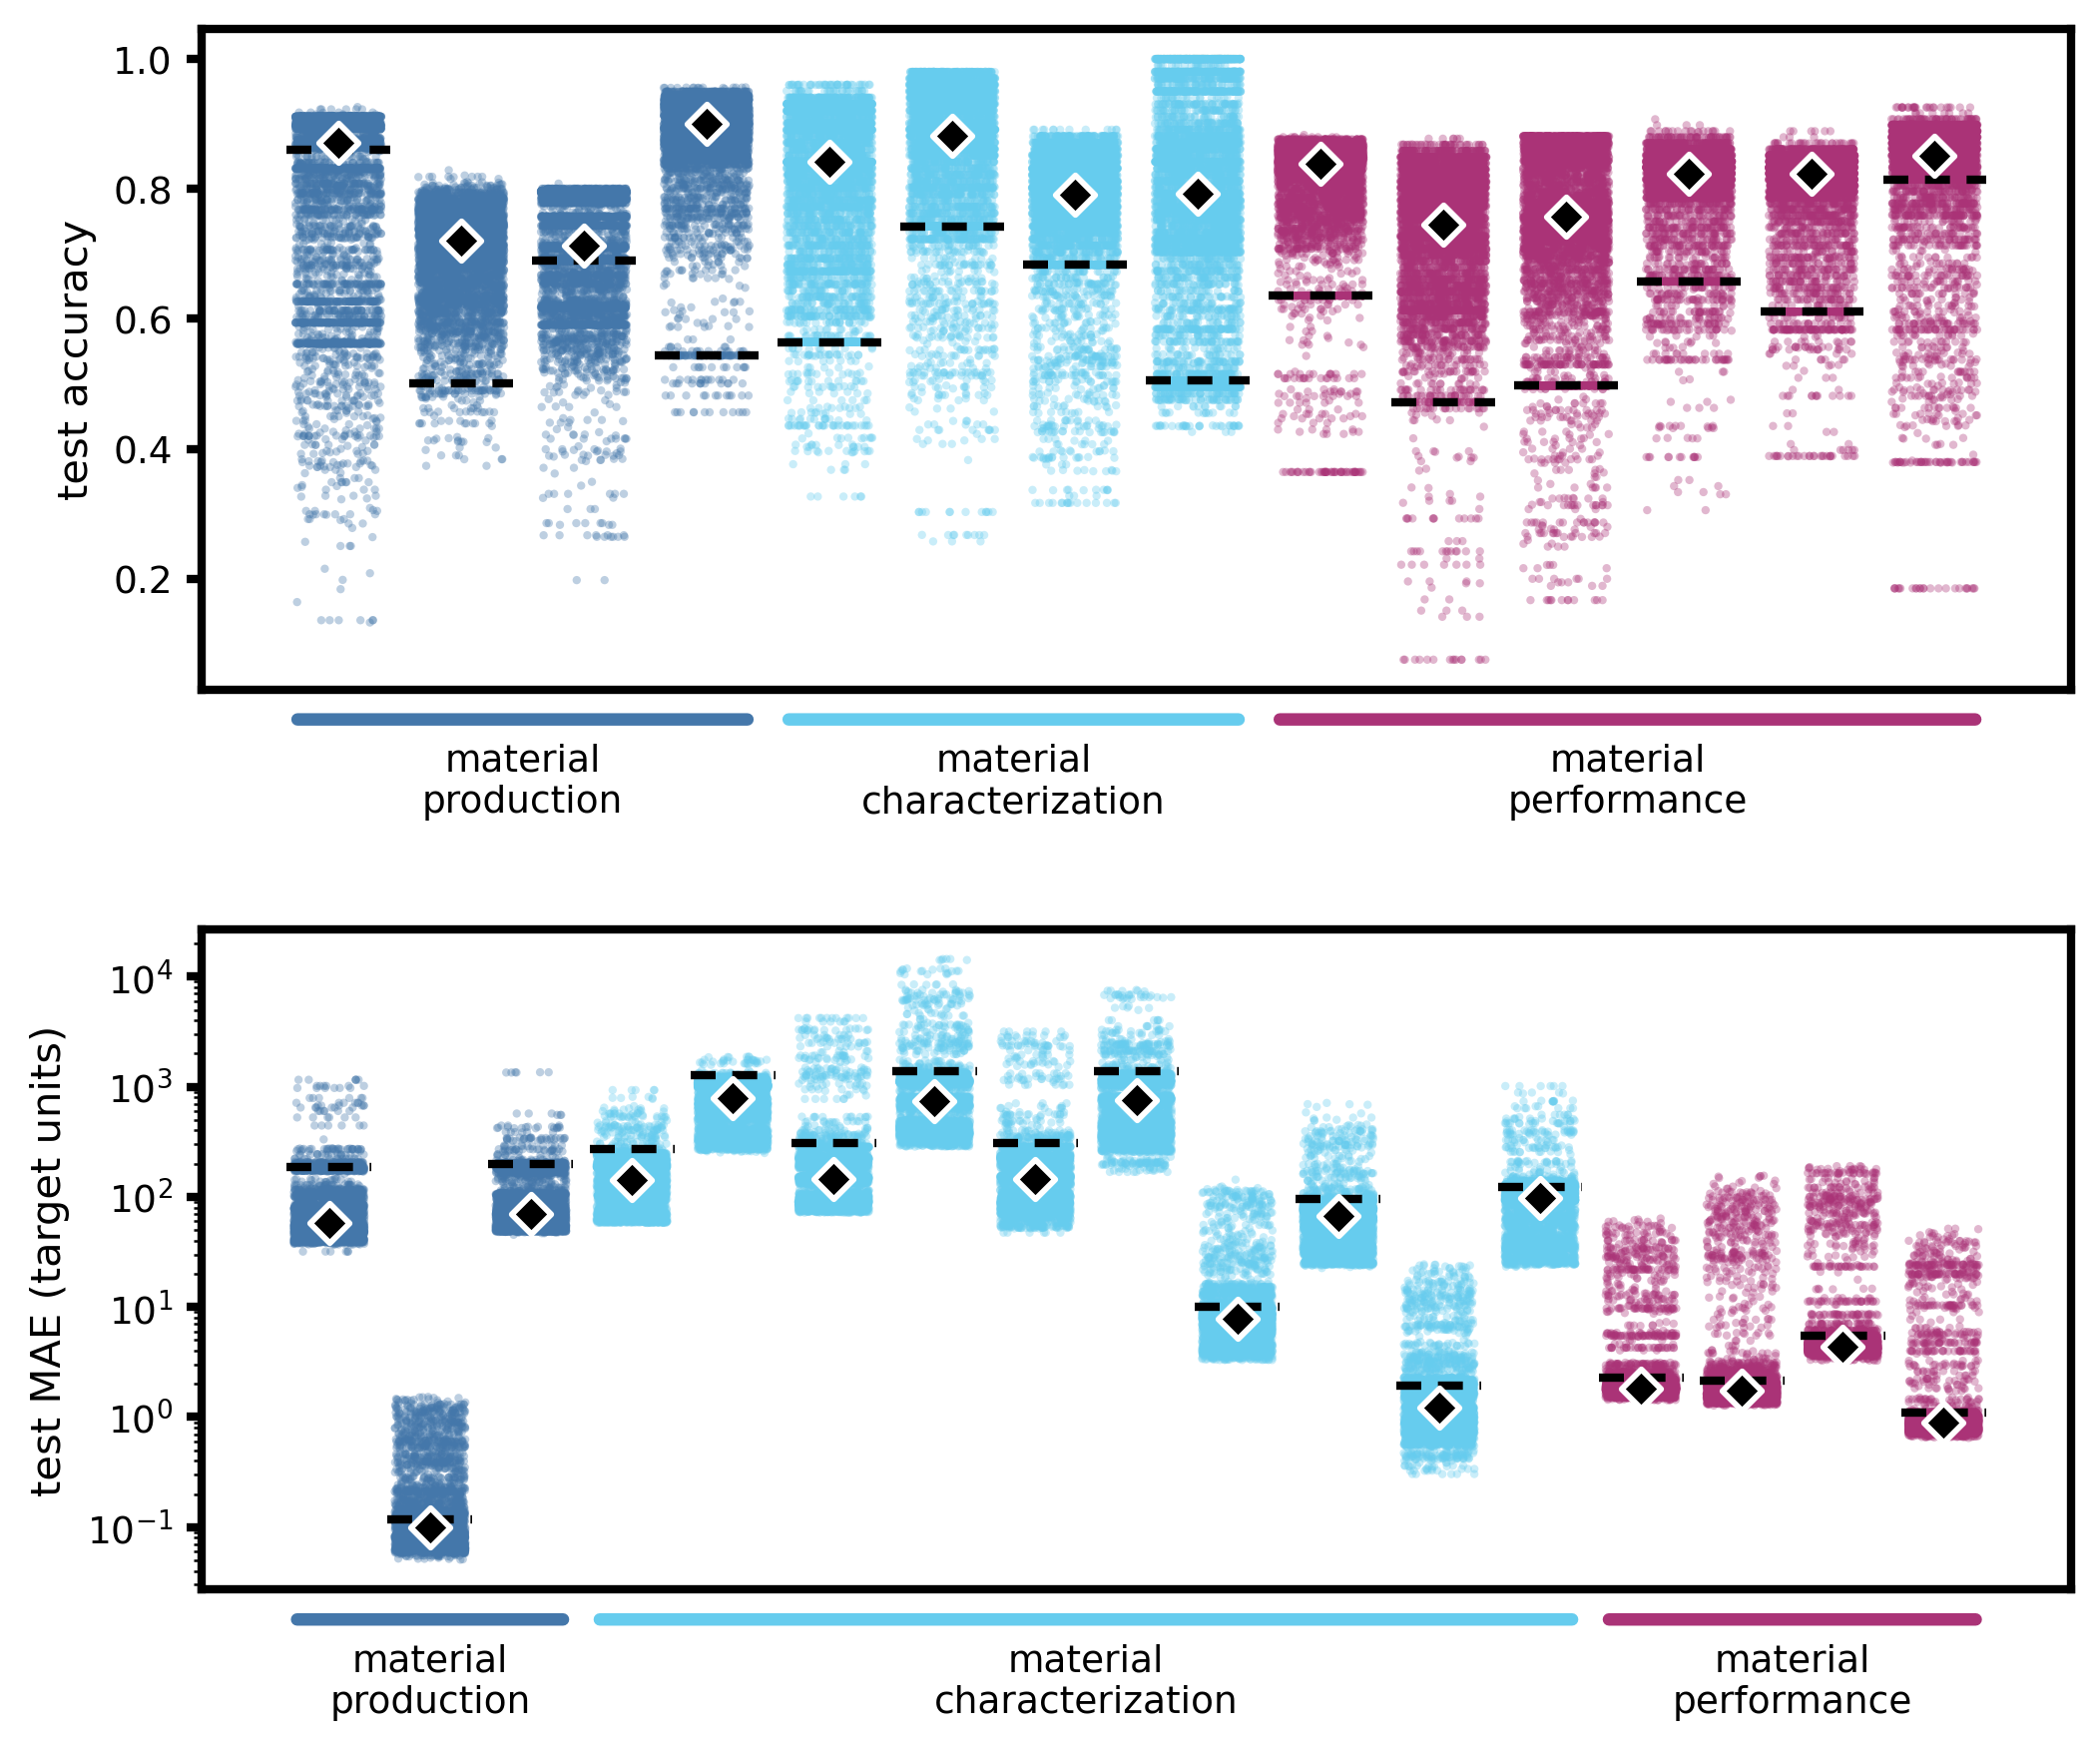

In [9]:
import seaborn as sns
from matplotlib.lines import Line2D

# vivid but colorblind-safe (blue / orange / purple — avoids red-green)
# domain_palette = {'production':'#1f77b4', 'characterization':'#ff7f0e',
#                   'performance':'#9467bd', 'other':'#999999'}
domain_palette = {'production':'#4477AA', 'characterization':'#66CCEE',
                  'performance':'#AA3377', 'other':'#999999'}


plt.rcParams.update({
    'axes.linewidth': 2.0,               # >= 2pt lines (spec)
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'xtick.major.width': 2.0, 'ytick.major.width': 2.0,   # >= 2pt
    'pdf.fonttype': 42, 'ps.fonttype': 42,                 # editable text in vector export
})

DOMAIN_ORDER = {'production':0, 'characterization':1, 'performance':2, 'other':3}
dsort = lambda t: sorted(t, key=lambda x: (DOMAIN_ORDER[DOMAIN[x]], x))
order_clf, order_reg = dsort(clf), dsort(reg)

# 180 mm wide; height chosen so it stays within one page and data isn't stretched
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(180/25.4, 150/25.4))

def panel(ax, df, order, ycol, medians, baseline=None):
    sns.stripplot(data=df, x='task', y=ycol, ax=ax, order=order,
                  size=2, alpha=0.35, jitter=0.35, hue='domain',
                  palette=domain_palette, legend=False)
    for i, t in enumerate(order):
        if baseline is not None:
            ax.hlines(baseline[t], i-0.42, i+0.42, color='black',
                      linewidth=2.0, linestyle=(0,(3,2)), zorder=8)
        ax.scatter(i, medians[t], marker='D', s=45, color='black',
                   edgecolor='white', linewidth=1.4, zorder=10)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0); ax.set_xlabel('')

    doms = [DOMAIN[t] for t in order]
    lbl = {'production':'material\nproduction', 'characterization':'material\ncharacterization',
           'performance':'material\nperformance'}
    BRACKET_Y = -0.045      # bracket sits further below the axis (was -0.015)
    LABEL_Y   = -0.08      # labels sit below the bracket with a gap (was -0.02)
    for d in ['production','characterization','performance']:
        idxs = [i for i,dd in enumerate(doms) if dd==d]
        if not idxs: continue
        c = (min(idxs)+max(idxs))/2
        col = domain_palette[d]                    # match the datapoint color
        ax.annotate(lbl[d], xy=(c, LABEL_Y), xycoords=('data','axes fraction'),
                    ha='center', va='top', fontsize=9, color='black',
                    annotation_clip=False)
        ax.annotate('', xy=(min(idxs)-0.4, BRACKET_Y), xytext=(max(idxs)+0.4, BRACKET_Y),
                    xycoords=('data','axes fraction'),
                    arrowprops=dict(arrowstyle='-', lw=3.0, color=col),
                    annotation_clip=False)


maj = {t: basic_info.loc[basic_info['File_name']==t, 'Majority_class'].iloc[0] for t in order_clf}
panel(ax0, df_clf, order_clf, 'mean_accuracy', med_acc, baseline=maj)
ax0.set_ylabel('test accuracy')          # unitless, bounded 0-1

#panel(ax1, df_reg, order_reg, 'mean_MAE', med_mae)
panel(ax1, df_reg, order_reg, 'mean_MAE', med_mae, baseline=reg_baseline)
ax1.set_yscale('log')
ax1.set_ylabel('test MAE (target units)')   # units noted per spec

fig.tight_layout(h_pad=3.0)

In [10]:
from pathlib import Path
figdir = REPO / "figures"; figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "Figure2_landscape.pdf", dpi=300, bbox_inches='tight')
fig.savefig(figdir / "Figure2_landscape.png", dpi=300, bbox_inches='tight')  # for quick viewing
print("saved to", figdir)

saved to C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\figures
